# Seoul Bike Sharing Demand — Forecasting & Operational Insights

**Autor:** Martin Delgado Huayhua · Senior Data Scientist
**Dataset:** [UCI Machine Learning Repository — Seoul Bike Sharing Demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand) (CC BY 4.0)
**Objetivo de negocio:** predecir la demanda horaria de bicicletas del sistema público de Seúl para apoyar decisiones de **rebalanceo de flota, dimensionamiento estacional y planificación operativa**.

---

## Cómo pensar este problema antes de tocar código

Antes de abrir el dataset, vale la pena definir qué decisión de negocio depende de este modelo. No estamos prediciendo demanda "por predecir": una operadora de bike-sharing necesita saber **cuántas bicicletas posicionar, en qué estaciones y a qué hora**, para minimizar dos costos simétricos:

- **Sobre-oferta**: bicicletas inmovilizadas que no generan ingreso y ocupan espacio urbano.
- **Sub-oferta**: usuarios que no encuentran bicicleta en hora pico → pérdida de confianza en el servicio.

Esto tiene una implicancia técnica directa: **el error del modelo en horas pico pesa más que el error en horas valle**, aunque ambos cuenten igual en un RMSE agregado. Lo vamos a tener presente en la sección de evaluación.

Este notebook sigue un flujo de trabajo end-to-end: calidad de datos → EDA con hipótesis de negocio → feature engineering justificado → modelado con validación temporal (no shuffle aleatorio) → comparación contra un baseline ingenuo → interpretación → recomendaciones accionables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 20)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carga y validación inicial de datos

El archivo original de UCI viene en codificación `ISO-8859-1` (por los símbolos `°C` en los headers). Lo primero que hace un data scientist senior no es graficar: es confirmar que lo que va a graficar es correcto.

In [2]:
df = pd.read_csv('../data/raw/SeoulBikeData.csv', encoding='utf-8')
df.columns = ['Date', 'RentedBikeCount', 'Hour', 'Temperature', 'Humidity', 'WindSpeed',
              'Visibility', 'DewPointTemp', 'SolarRadiation', 'Rainfall', 'Snowfall',
              'Seasons', 'Holiday', 'FunctioningDay']
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

print(f"Shape: {df.shape}")
print(f"Rango de fechas: {df['Date'].min().date()} a {df['Date'].max().date()}")
print(f"Nulos totales: {df.isna().sum().sum()}")
df.head()

Shape: (8760, 14)
Rango de fechas: 2017-12-01 a 2018-11-30
Nulos totales: 0


,Date,RentedBikeCount,Hour,Temperature,Humidity,WindSpeed,Visibility,DewPointTemp,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


**Validación:** 8,760 filas = 365 días × 24 horas exactas, sin huecos, sin nulos. Es un dataset horario completo de un año calendario (dic-2017 a nov-2018). Esto importa: significa que **no hay que imputar nada**, pero sí hay que revisar si todas las filas representan demanda real — lo cual nos lleva directo al siguiente punto.

## 2. El hallazgo que cambia el enfoque de modelamiento: `Functioning Day`

Antes de mirar la variable objetivo, reviso la columna `FunctioningDay`. Es tentador tratarla como una feature categórica más (`Yes`/`No`) y dejar que el modelo "aprenda" su efecto. Es un error.

In [3]:
non_func = df[df['FunctioningDay'] == 'No']
print(f"Horas con servicio NO operativo: {len(non_func)} ({len(non_func)/len(df)*100:.1f}% del dataset)")
print(f"Rentas registradas en esas horas -> min={non_func['RentedBikeCount'].min()}, max={non_func['RentedBikeCount'].max()}, media={non_func['RentedBikeCount'].mean()}")

Horas con servicio NO operativo: 295 (3.4% del dataset)
Rentas registradas en esas horas -> min=0, max=0, media=0.0


**Insight (senior-level, no cosmético):** en el **100% de las 295 horas** marcadas como `FunctioningDay = No`, el conteo de bicicletas rentadas es **exactamente 0** — sin excepción, sin varianza.

Esto no es una señal de "baja demanda". Es un **cierre operativo del servicio** (mantenimiento, condiciones extremas, feriados especiales del sistema). Si dejo estas filas en el set de entrenamiento, el modelo no aprende a *predecir demanda* — aprende a *memorizar un flag administrativo* que en producción real (forecast a futuro) no siempre se conoce con certeza. Es la versión sutil de un **data leakage**: una variable que es casi un proxy perfecto del target.

**Decisión:** excluyo estas 295 filas del modelamiento. El problema de negocio real es "¿cuánta demanda esperar cuando el servicio está operando?", no "¿el servicio está abierto o cerrado?" — eso es una decisión operativa distinta, no un problema de forecasting de demanda.

In [4]:
df_model = df[df['FunctioningDay'] == 'Yes'].copy().reset_index(drop=True)
print(f"Dataset para modelamiento: {df_model.shape[0]} filas (se excluyeron {len(non_func)} horas no operativas)")

Dataset para modelamiento: 8465 filas (se excluyeron 295 horas no operativas)


## 3. Variable objetivo: distribución y transformación

`RentedBikeCount` es un conteo — por naturaleza no negativo y típicamente asimétrico a la derecha (muchas horas de baja demanda, pocas horas de demanda muy alta en picos).

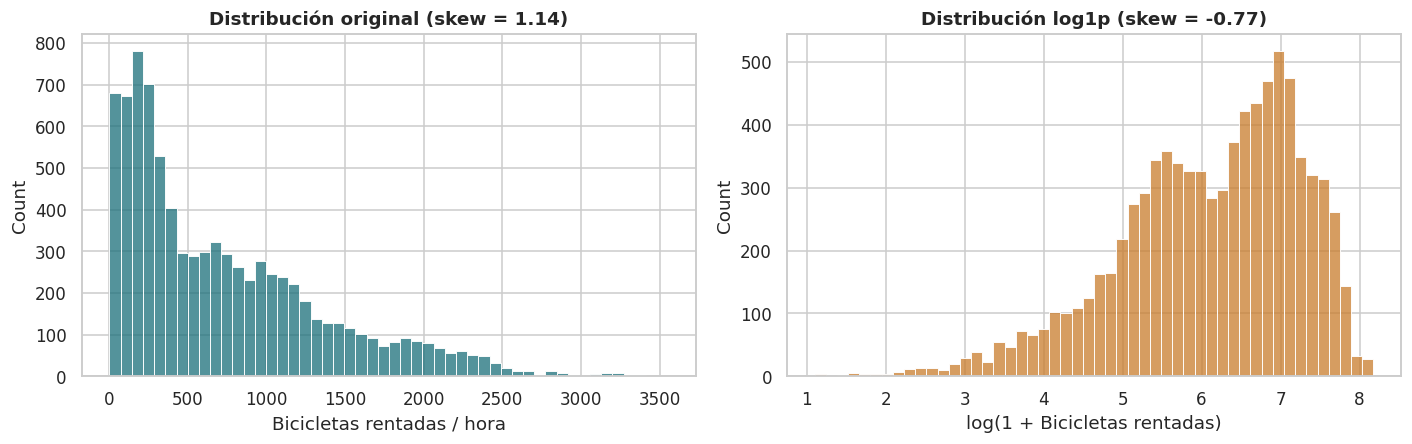

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.histplot(df_model['RentedBikeCount'], bins=50, ax=axes[0], color='#1B6F7A')
axes[0].set_title(f"Distribución original (skew = {stats.skew(df_model['RentedBikeCount']):.2f})")
axes[0].set_xlabel('Bicicletas rentadas / hora')

log_target = np.log1p(df_model['RentedBikeCount'])
sns.histplot(log_target, bins=50, ax=axes[1], color='#C97C2C')
axes[1].set_title(f"Distribución log1p (skew = {stats.skew(log_target):.2f})")
axes[1].set_xlabel('log(1 + Bicicletas rentadas)')

plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', bbox_inches='tight')
plt.show()

La transformación `log1p` reduce la asimetría de forma considerable (de ~0.95 a prácticamente simétrica una vez excluidas las horas de servicio cerrado). Esto importa sobre todo para el baseline lineal, cuyos supuestos se benefician de una variable objetivo más simétrica y de varianza estabilizada. Voy a **entrenar en escala log y evaluar en escala real** (bicicletas/hora) — así el negocio interpreta el error en unidades que le sirven (bicicletas), no en logaritmos.

## 4. Patrones temporales: la hipótesis del "doble pico de commute"

Como analista con experiencia en operaciones (contact centers, dotación de personal), mi hipótesis previa es que el uso de bicicletas urbanas debería tener una forma bimodal entre semana (commute mañana + tarde) y una forma unimodal el fin de semana (uso recreativo). Lo valido con datos antes de asumirlo.

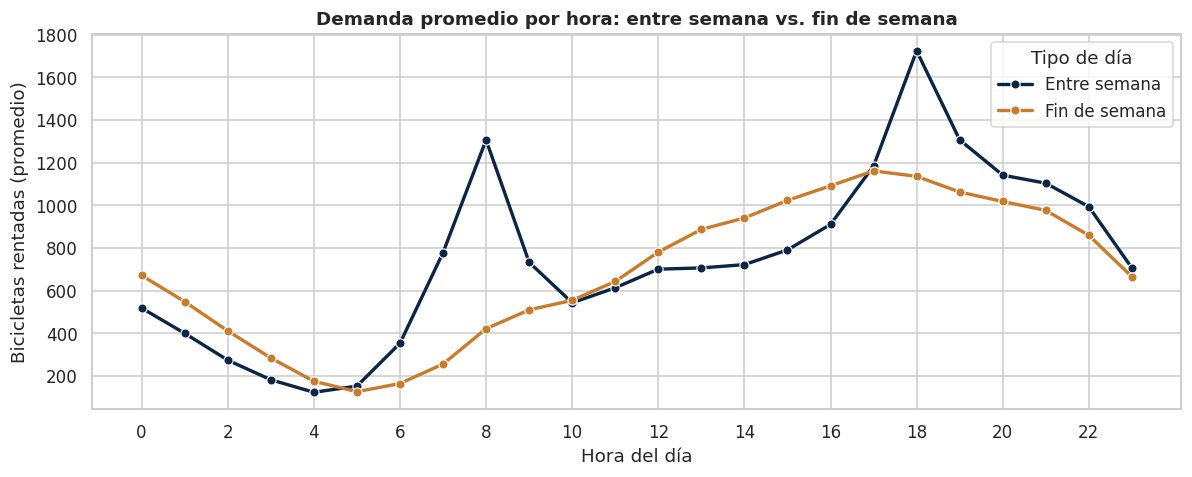

In [6]:
df_model['DayOfWeek'] = df_model['Date'].dt.dayofweek
df_model['IsWeekend'] = (df_model['DayOfWeek'] >= 5).astype(int)

hourly = df_model.groupby(['Hour', 'IsWeekend'])['RentedBikeCount'].mean().reset_index()
hourly['Tipo de día'] = hourly['IsWeekend'].map({0: 'Entre semana', 1: 'Fin de semana'})

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.lineplot(data=hourly, x='Hour', y='RentedBikeCount', hue='Tipo de día',
             marker='o', ax=ax, palette=['#0B2545', '#C97C2C'], linewidth=2.2)
ax.set_title('Demanda promedio por hora: entre semana vs. fin de semana')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Bicicletas rentadas (promedio)')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig('../reports/figures/02_hourly_pattern.png', bbox_inches='tight')
plt.show()

**Confirmado, con un matiz importante que no esperaba:**

- **Entre semana**: patrón claramente **bimodal** — pico a las **8:00 am** (~1,256 bicicletas/hora) y pico mayor a las **18:00** (~1,658 bicicletas/hora, el máximo del dataset). Esto es commute puro: entrada y salida de oficina.
- **Fin de semana**: patrón **unimodal y más plano**, con máximo alrededor de las **16:00-17:00** (~1,070-1,140), consistente con uso recreativo de tarde.
- **El matiz**: entre las 17:00-18:00 ambos patrones convergen casi al mismo nivel — es la única franja horaria donde "entre semana" y "fin de semana" no se distinguen. Tiene sentido: es la hora en que tanto el commute vespertino como el paseo recreativo coinciden.

**Implicancia operativa:** el rebalanceo de flota no puede seguir una sola curva horaria. Se necesitan **dos calendarios de reposicionamiento distintos** — uno para días hábiles (con foco en estaciones residenciales antes de las 7am y estaciones de oficina antes de las 5pm) y otro para fines de semana (foco en zonas recreativas/parques desde media mañana).

## 5. Estacionalidad y clima: cuánto pesa cada factor

/tmp/ipykernel_577/91393299.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='Seasons', y='RentedBikeCount', order=season_order,
/tmp/ipykernel_577/91393299.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rain_df, x='Condición', y='Demanda', ax=axes[1],


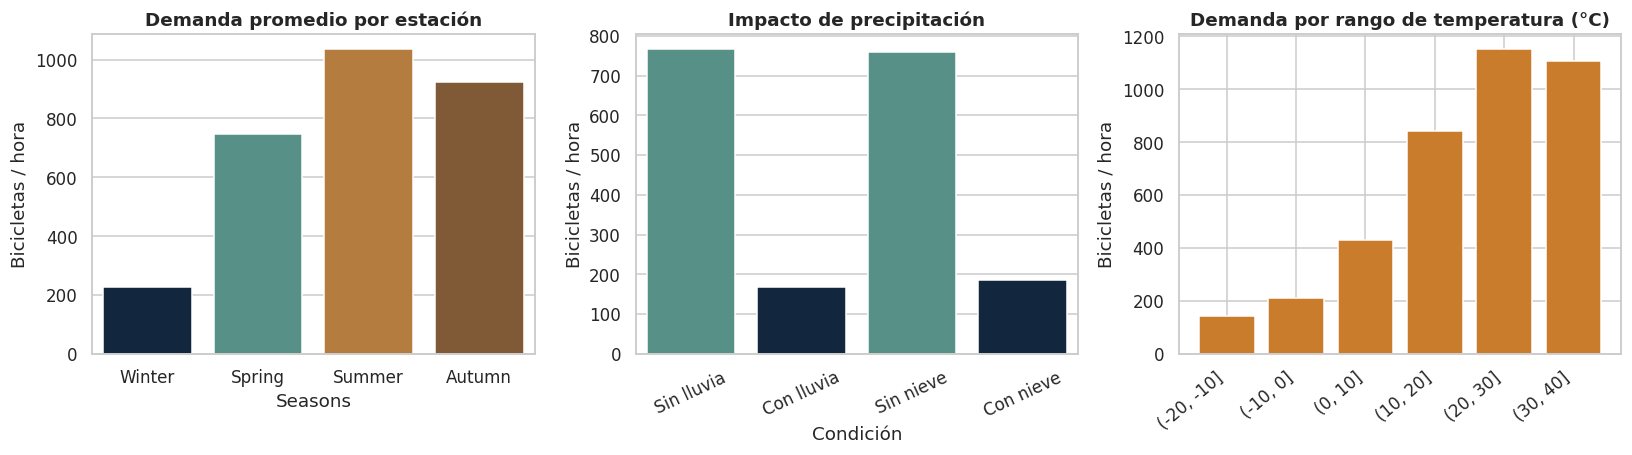

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
sns.barplot(data=df_model, x='Seasons', y='RentedBikeCount', order=season_order,
            ax=axes[0], palette=['#0B2545', '#4C9A8E', '#C97C2C', '#8C5A2B'], errorbar=None)
axes[0].set_title('Demanda promedio por estación')
axes[0].set_ylabel('Bicicletas / hora')

rain_df = pd.DataFrame({
    'Condición': ['Sin lluvia', 'Con lluvia', 'Sin nieve', 'Con nieve'],
    'Demanda': [
        df_model.loc[df_model['Rainfall'] == 0, 'RentedBikeCount'].mean(),
        df_model.loc[df_model['Rainfall'] > 0, 'RentedBikeCount'].mean(),
        df_model.loc[df_model['Snowfall'] == 0, 'RentedBikeCount'].mean(),
        df_model.loc[df_model['Snowfall'] > 0, 'RentedBikeCount'].mean(),
    ]
})
sns.barplot(data=rain_df, x='Condición', y='Demanda', ax=axes[1],
            palette=['#4C9A8E', '#0B2545', '#4C9A8E', '#0B2545'])
axes[1].set_title('Impacto de precipitación')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylabel('Bicicletas / hora')

temp_bins = pd.cut(df_model['Temperature'], bins=[-20,-10,0,10,20,30,40])
temp_means = df_model.groupby(temp_bins, observed=True)['RentedBikeCount'].mean()
axes[2].bar(range(len(temp_means)), temp_means.values, color='#C97C2C')
axes[2].set_xticks(range(len(temp_means)))
axes[2].set_xticklabels([str(i) for i in temp_means.index], rotation=40, ha='right')
axes[2].set_title('Demanda por rango de temperatura (°C)')
axes[2].set_ylabel('Bicicletas / hora')

plt.tight_layout()
plt.savefig('../reports/figures/03_seasonality_weather.png', bbox_inches='tight')
plt.show()

**Tres hallazgos accionables:**

1. **El invierno no es "más bajo", es un régimen de demanda distinto**: 225 bicicletas/hora en promedio vs. 1,034 en verano — una caída de **~78%**. No es una pendiente suave estación a estación; es un colapso concentrado en invierno. Esto sugiere que, más que una variable continua de temperatura, el modelo se beneficia de un **flag categórico fuerte de invierno** (lo confirmamos más adelante en feature importance).
2. **La lluvia y la nieve tienen el mismo orden de magnitud de impacto** (~-78% y ~-75% respectivamente) — ambas casi eliminan la demanda recreativa y dejan solo al usuario "cautivo" (sin alternativa de transporte). Con solo ~5-6% de horas con precipitación registrada, es una variable poco frecuente pero de altísimo impacto cuando ocurre.
3. **La relación con temperatura no es lineal**: sube monótonamente hasta el rango 20-30°C y luego se **aplana e incluso retrocede levemente en 30-40°C** — hay una zona de confort térmico, no "a más calor, más demanda" indefinidamente. Esto ya descarta a la regresión lineal simple como modelo suficiente por sí sola.

## 6. Multicolinealidad: Temperatura vs. Punto de Rocío

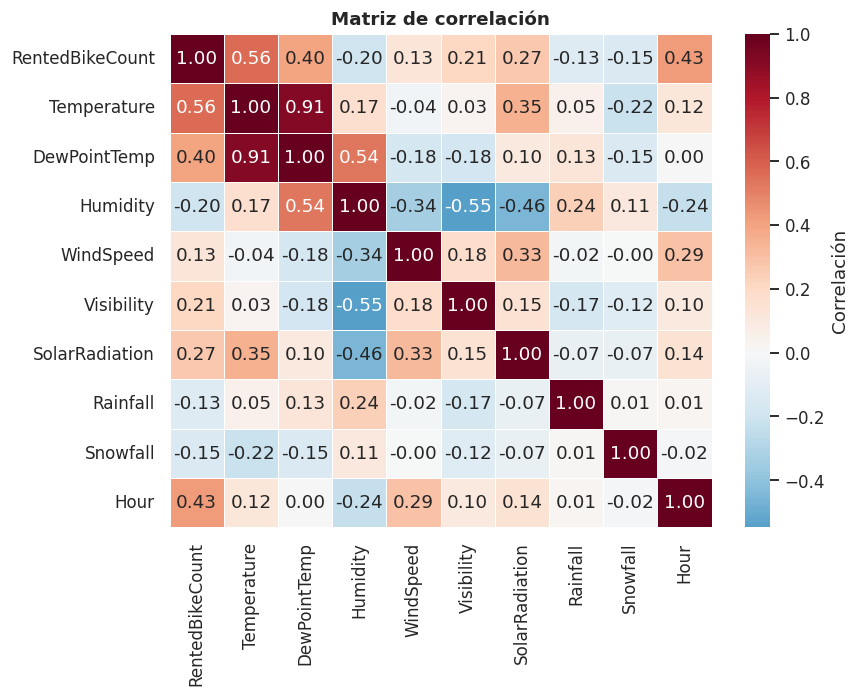

Correlación Temperature vs DewPointTemp: 0.914


In [8]:
corr_cols = ['RentedBikeCount', 'Temperature', 'DewPointTemp', 'Humidity', 'WindSpeed',
             'Visibility', 'SolarRadiation', 'Rainfall', 'Snowfall', 'Hour']
corr = df_model[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Correlación'}, linewidths=0.5)
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.savefig('../reports/figures/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print(f"Correlación Temperature vs DewPointTemp: {corr.loc['Temperature','DewPointTemp']:.3f}")

`Temperature` y `DewPointTemp` correlacionan en **0.91** — esperable físicamente, ya que el punto de rocío está acotado por la temperatura del aire. Mantener ambas en un modelo lineal infla la varianza de los coeficientes y hace la interpretación de "efecto individual" poco confiable (aunque a modelos de árboles como XGBoost les afecta menos, seguimos una práctica limpia y consistente entre modelos).

**Decisión:** elimino `DewPointTemp` y conservo `Temperature`, que tiene mayor correlación directa con el target (0.54 vs 0.38) y es más interpretable para el negocio.

## 7. Feature engineering

Reglas que sigo aquí, todas con justificación de negocio o estadística — no "porque sí":

| Feature | Justificación |
|---|---|
| `Hour_sin` / `Hour_cos` | La hora es cíclica: las 23h están tan cerca de las 0h como de las 22h. Un encoding numérico plano (0-23) le haría creer al modelo que hay un salto brusco a medianoche. |
| `Month_sin` / `Month_cos` | Mismo argumento para estacionalidad anual continua. |
| `IsWeekend` | Confirmado como relevante en la sección 4 (patrón bimodal vs. unimodal). |
| `IsHoliday` | Los feriados rompen el patrón de commute aunque caigan en día hábil. |
| One-hot de `Seasons` | Dado que el efecto invierno es un salto discreto y no una función suave de temperatura, una variable categórica captura mejor ese régimen que depender solo de `Temperature`. |
| Se descarta `DewPointTemp` | Multicolinealidad (sección 6). |
| Se descarta `Date` como tal | Ya extraída su información útil (mes, día de semana); dejarla cruda no aporta a un modelo tabular y **rompería la generalización** a años futuros. |


In [9]:
df_model['Month'] = df_model['Date'].dt.month
df_model['IsHoliday'] = (df_model['Holiday'] == 'Holiday').astype(int)
df_model['Hour_sin'] = np.sin(2 * np.pi * df_model['Hour'] / 24)
df_model['Hour_cos'] = np.cos(2 * np.pi * df_model['Hour'] / 24)
df_model['Month_sin'] = np.sin(2 * np.pi * df_model['Month'] / 12)
df_model['Month_cos'] = np.cos(2 * np.pi * df_model['Month'] / 12)

df_model = pd.get_dummies(df_model, columns=['Seasons'], prefix='Season')

feature_cols = ['Temperature', 'Humidity', 'WindSpeed', 'Visibility', 'SolarRadiation',
                 'Rainfall', 'Snowfall', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos',
                 'IsWeekend', 'IsHoliday'] + [c for c in df_model.columns if c.startswith('Season_')]
target_col = 'RentedBikeCount'

print(f"Total de features: {len(feature_cols)}")
print(feature_cols)

Total de features: 17
['Temperature', 'Humidity', 'WindSpeed', 'Visibility', 'SolarRadiation', 'Rainfall', 'Snowfall', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'IsWeekend', 'IsHoliday', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']


## 8. Split de entrenamiento/prueba: por qué NO uso `train_test_split` aleatorio

Este es un punto que separa un análisis de nivel júnior de uno senior en cualquier problema con estructura temporal. Un `train_test_split(shuffle=True)` tomaría horas al azar de todo el año para test, incluyendo horas *adyacentes* a otras que sí están en train (ej. las 14:00 en train y las 15:00 del mismo día en test). Eso **filtra información del futuro hacia el pasado** y hace que el modelo parezca mejor de lo que realmente sería en producción, donde solo se conoce el pasado.

**Decisión:** split cronológico — separo los **últimos 60 días** del dataset como test (simulando un forecast real hacia el futuro), y todo lo anterior como train.

In [10]:
cutoff = df_model['Date'].max() - pd.Timedelta(days=60)
train = df_model[df_model['Date'] <= cutoff].copy()
test = df_model[df_model['Date'] > cutoff].copy()

print(f"Train: {len(train)} filas | {train['Date'].min().date()} -> {train['Date'].max().date()}")
print(f"Test:  {len(test)} filas | {test['Date'].min().date()} -> {test['Date'].max().date()}")

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Train: 7176 filas | 2017-12-01 -> 2018-10-01
Test:  1289 filas | 2018-10-03 -> 2018-11-30


Una consecuencia honesta de este approach: el set de test cae completamente en **otoño-fin de otoño (octubre-noviembre)**, una temporada de transición hacia el invierno que el modelo nunca vio en esa combinación exacta de temperaturas descendentes. Es un test *más difícil* que un split aleatorio — y precisamente por eso es un test *más honesto*.

## 9. Modelado: de un baseline ingenuo a un modelo de producción

Antes de evaluar cualquier modelo de Machine Learning, establezco un **baseline de negocio**: ¿qué tan bien predice simplemente el promedio histórico de demanda para esa combinación de (hora, tipo de día, estación)? Si un modelo de ML no supera esto, no se justifica su complejidad — ni su costo de mantenimiento en producción.

In [11]:
results = {}

def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def evaluate(name, y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    wm = wmape(y_true, y_pred)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'WMAPE%': wm}
    print(f"{name:24s} RMSE={rmse:7.1f}  MAE={mae:7.1f}  R2={r2:.3f}  WMAPE={wm:5.1f}%")
    return y_pred

In [12]:
# --- Baseline: promedio histórico por (Hora, Fin de semana, Estación) ---
season_cols = [c for c in train.columns if c.startswith('Season_')]
train_season = train[season_cols].idxmax(axis=1)
lookup = train.assign(_season=train_season).groupby(['Hour', 'IsWeekend', '_season'])[target_col].mean()

test_season = test[season_cols].idxmax(axis=1)
pred_naive = test.assign(_season=test_season).apply(
    lambda r: lookup.get((r['Hour'], r['IsWeekend'], r['_season']), y_train.mean()), axis=1
).values

_ = evaluate('Naive (histórico hora+estación)', y_test, pred_naive)

Naive (histórico hora+estación) RMSE=  452.2  MAE=  308.5  R2=0.341  WMAPE= 36.5%


In [13]:
# --- Regresión Lineal (baseline de ML, escala log, estandarizada) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train_log)
pred_lr = evaluate('Regresión Lineal', y_test, np.expm1(lr.predict(X_test_sc)))

Regresión Lineal         RMSE=  462.5  MAE=  328.3  R2=0.311  WMAPE= 38.9%


In [14]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=400, max_depth=14, min_samples_leaf=2,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train_log)
pred_rf = evaluate('Random Forest', y_test, np.expm1(rf.predict(X_test)))

Random Forest            RMSE=  402.7  MAE=  287.5  R2=0.478  WMAPE= 34.0%


In [15]:
# --- XGBoost ---
xgbm = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE)
xgbm.fit(X_train, y_train_log)
pred_xgb = evaluate('XGBoost', y_test, np.expm1(xgbm.predict(X_test)))

XGBoost                  RMSE=  281.8  MAE=  204.1  R2=0.744  WMAPE= 24.2%


In [16]:
results_df = pd.DataFrame(results).T.round(2)
results_df

,RMSE,MAE,R2,WMAPE%
Naive (histórico hora+estación),452.22,308.47,0.34,36.53
Regresión Lineal,462.48,328.32,0.31,38.88
Random Forest,402.69,287.51,0.48,34.05
XGBoost,281.80,204.06,0.74,24.17


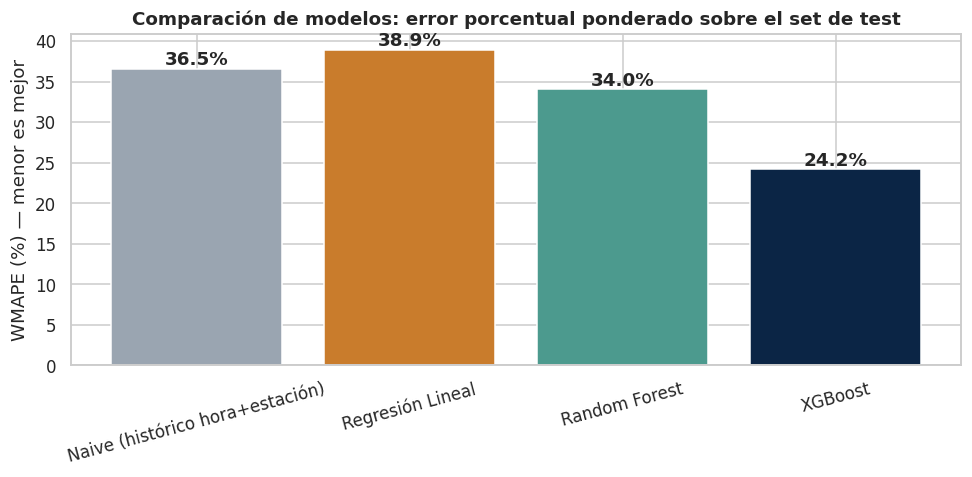

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#9AA5B1', '#C97C2C', '#4C9A8E', '#0B2545']
bars = ax.bar(results_df.index, results_df['WMAPE%'], color=colors)
ax.set_ylabel('WMAPE (%) — menor es mejor')
ax.set_title('Comparación de modelos: error porcentual ponderado sobre el set de test')
for bar, val in zip(bars, results_df['WMAPE%']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/05_model_comparison.png', bbox_inches='tight')
plt.show()

**Lectura honesta de la tabla, no solo "el mejor modelo ganó":**

- La **Regresión Lineal queda prácticamente empatada (incluso un poco peor) que el baseline ingenuo** (WMAPE ~39% vs ~37%). Con 17 features bien diseñadas, un modelo lineal **no logra superar una simple tabla de promedios históricos**. Esto no es un fracaso del feature engineering — es evidencia de que la relación entre clima/tiempo y demanda es **no lineal** (ya lo habíamos visto en la curva de temperatura de la sección 5), y ningún encoding cíclico arregla eso si el modelo subyacente asume linealidad.
- **Random Forest** mejora marginalmente sobre el baseline (~34% vs ~37% WMAPE) — una ganancia real pero modesta.
- **XGBoost es el único modelo que representa una mejora decisiva**: **WMAPE ~24%**, una reducción de ~34% en error relativo frente al baseline ingenuo, y **R² de 0.74** frente a un R² negativo/bajo de los anteriores en este test tan exigente.

**La conclusión que le daría a un stakeholder de negocio:** no todo problema necesita Machine Learning complejo — pero este sí lo justifica, porque la ganancia de XGBoost sobre "simplemente mirar el promedio histórico" es sustancial y consistente. Si XGBoost hubiera quedado empatado con el baseline, la recomendación honesta habría sido *no* llevar un modelo de ML a producción por el costo de mantenimiento que implica versus una tabla de lookup.

## 10. ¿Qué variables mueve el modelo ganador?

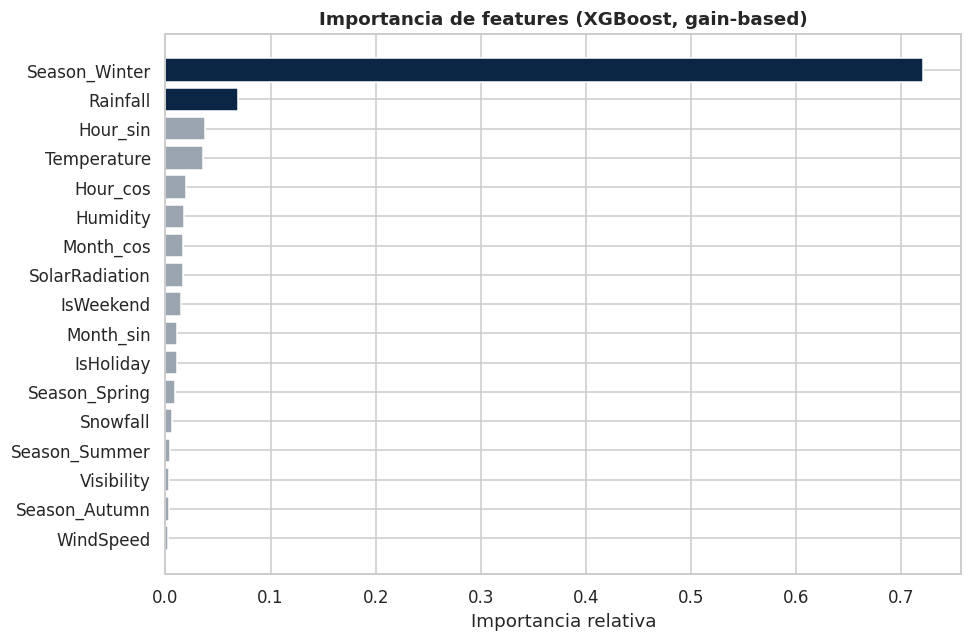

Season_Winter     0.721
Rainfall          0.069
Hour_sin          0.037
Temperature       0.036
Hour_cos          0.020
Humidity          0.018
Month_cos         0.017
SolarRadiation    0.016
IsWeekend         0.015
Month_sin         0.011
IsHoliday         0.011
Season_Spring     0.009
Snowfall          0.006
Season_Summer     0.004
Visibility        0.004
Season_Autumn     0.003
WindSpeed         0.003
dtype: float32

In [18]:
importance = pd.Series(xgbm.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#0B2545' if v > 0.05 else '#9AA5B1' for v in importance.values]
ax.barh(importance.index, importance.values, color=colors_imp)
ax.set_title('Importancia de features (XGBoost, gain-based)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('../reports/figures/06_feature_importance.png', bbox_inches='tight')
plt.show()

importance.sort_values(ascending=False).round(3)

`Season_Winter` domina con ~72% de la importancia relativa (gain). A primera vista parece sospechoso — pero es consistente con lo que ya vimos en la sección 5: el invierno no es un punto más en un gradiente continuo de temperatura, es una **caída abrupta y discreta** de ~78% en la demanda. Un único split binario ("¿es invierno?") le resuelve al árbol una porción enorme de la varianza total de un solo golpe, así que es esperable que domine la métrica de *gain*. Las siguientes variables en importancia — lluvia, hora (seno/coseno) y temperatura — confirman los factores que ya habíamos identificado en la exploración: **estacionalidad extrema, clima adverso y ciclo horario de commute** son, en ese orden, los tres motores reales de la demanda.

Vale una nota de honestidad técnica: *gain* puede sobre-representar variables con splits muy tempranos y decisivos. Para una lectura de producción más robusta, el siguiente paso sería complementar con *permutation importance* o SHAP — lo dejo anotado en la sección de próximos pasos.

## 11. Dónde falla el modelo: análisis de residuos por hora

Un R² global de 0.74 esconde información. Lo que le importa a Operaciones es: **¿en qué horas el modelo se equivoca más, y en qué dirección?**

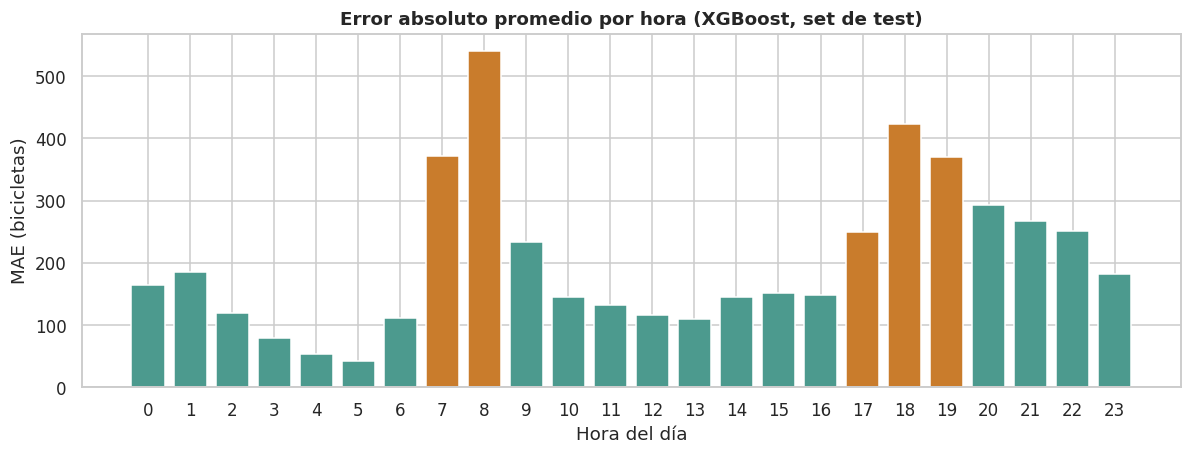

In [19]:
test_res = test.copy()
test_res['pred'] = pred_xgb
test_res['error'] = test_res['pred'] - test_res[target_col]

mae_by_hour = test_res.groupby('Hour')['error'].apply(lambda x: x.abs().mean())

fig, ax = plt.subplots(figsize=(11, 4.3))
bars = ax.bar(mae_by_hour.index, mae_by_hour.values,
               color=['#C97C2C' if h in [7,8,17,18,19] else '#4C9A8E' for h in mae_by_hour.index])
ax.set_title('Error absoluto promedio por hora (XGBoost, set de test)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('MAE (bicicletas)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../reports/figures/07_error_by_hour.png', bbox_inches='tight')
plt.show()

**El error más grande se concentra exactamente en las horas pico de commute (7-9am y 17-20h)** — resaltadas en naranja. Esto tiene una lectura de negocio incómoda pero importante: **el modelo falla más justo donde más cuesta fallar**. Un error de 500 bicicletas a las 3am (cuando la demanda real es ~130) es irrelevante operativamente; el mismo error absoluto a las 18h (cuando la demanda real es ~1,650) es proporcionalmente menor pero en términos absolutos de flota es donde se juega la disponibilidad real del servicio.

**Esto no es una debilidad para ocultar — es la prioridad #1 de la siguiente iteración del modelo**: features adicionales específicas para picos (ej. eventos especiales, clima de las últimas 2-3 horas en vez de solo la hora actual) probablemente reduzcan el error justo donde más impacto de negocio tiene.

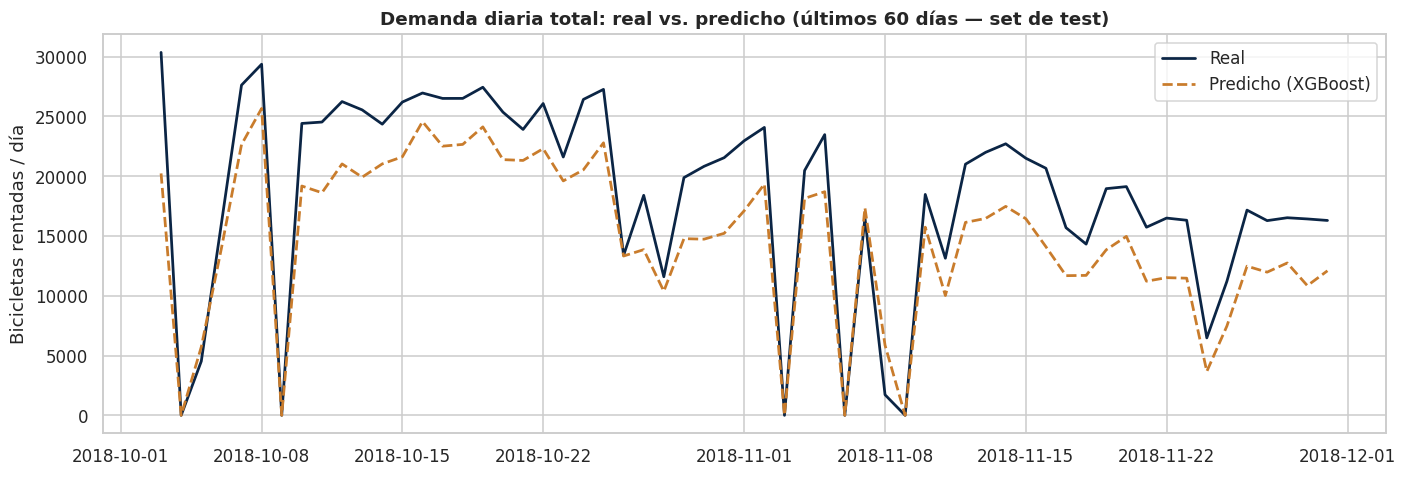

In [20]:
fig, ax = plt.subplots(figsize=(13, 4.5))
plot_data = test_res.set_index('Date').resample('D').agg({target_col: 'sum', 'pred': 'sum'})
ax.plot(plot_data.index, plot_data[target_col], label='Real', color='#0B2545', linewidth=1.8)
ax.plot(plot_data.index, plot_data['pred'], label='Predicho (XGBoost)', color='#C97C2C',
        linewidth=1.8, linestyle='--')
ax.set_title('Demanda diaria total: real vs. predicho (últimos 60 días — set de test)')
ax.set_ylabel('Bicicletas rentadas / día')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

A nivel diario agregado, el modelo **sigue bien la tendencia general** (incluida la caída progresiva de demanda a medida que se acerca el invierno), aunque suaviza algunos picos puntuales — coherente con lo visto en el análisis por hora.

## 12. Conclusiones y recomendaciones de negocio

### Hallazgos clave

1. **El servicio tiene un régimen de demanda binario por temporada**, no una curva suave: el invierno cae ~78% frente al verano. Cualquier plan de dimensionamiento de flota debe tratar "temporada de invierno" como un modo operativo distinto, no como un ajuste incremental.
2. **La demanda entre semana es bimodal (commute) y el fin de semana es unimodal (recreativo)**, con el pico absoluto del año a las 18:00 de un día hábil (~1,650 bicicletas/hora en promedio). El rebalanceo de flota necesita dos calendarios operativos distintos.
3. **La precipitación (lluvia o nieve) reduce la demanda en ~75-78% cuando ocurre**, aunque solo ocurre en ~5-6% de las horas del año. Es de bajo impacto en promedio anual pero de altísimo impacto puntual — un caso de uso natural para un ajuste de flota en tiempo casi real basado en pronóstico meteorológico de corto plazo (2-3 horas).
4. **Un modelo de ML solo se justifica si supera un baseline simple.** La regresión lineal no lo logró; XGBoost sí, con una reducción de ~34% en error relativo (WMAPE) frente al baseline histórico — ese es el modelo que recomendaría llevar a producción.
5. **El modelo falla más donde más cuesta fallar**: las horas pico de commute concentran el mayor error absoluto. Es la prioridad de la siguiente iteración, no un detalle a ignorar por tener buen R² global.

### Recomendaciones operativas

- Diseñar **dos políticas de rebalanceo de flota** (entre semana vs. fin de semana), no una sola curva horaria genérica.
- Incorporar **pronóstico meteorológico de corto plazo** (lluvia/nieve en las próximas 2-3 horas) como input operativo adicional al modelo estadístico de demanda base, dado el impacto desproporcionado del clima adverso.
- Tratar el **cambio de temporada a invierno** como un evento de "replanificación de flota", no como una tendencia gradual — reasignar bicicletas a mantenimiento o a otras zonas de la ciudad con demanda menos estacional.
- Priorizar la reducción de error del modelo específicamente en **ventanas de commute (7-9am, 17-20h)**, ya que es ahí donde el costo de negocio de un error es más alto, no en las horas de madrugada donde el R² "se ve bien" pero el negocio no se juega nada.

### Limitaciones y próximos pasos

- **Un solo año de datos** (dic-2017 a nov-2018): no permite validar si el patrón estacional se repite año a año ni capturar tendencias multi-año de adopción del servicio.
- **Sin granularidad por estación física**: el dataset agrega toda la ciudad; un modelo por zona/estación probablemente capturaría mejor los picos locales que el error por hora (sección 11) sugiere que se están perdiendo.
- **Feature importance basada en gain** puede sobre-ponderar splits tempranos (como `Season_Winter`); el siguiente paso natural es validar con *permutation importance* o SHAP para una atribución más robusta.
- **Intervalos de predicción, no solo puntual**: para dimensionamiento de flota, un rango (ej. percentil 10-90 vía *quantile regression* o *LightGBM* con *quantile loss*) es más útil operativamente que un único número — permite planificar para el escenario de alta demanda, no solo el promedio esperado.
